# 💳 Credit Card Customer Segmentation using Unsupervised Learning

## 📌 Project Overview
This project aims to segment credit card customers based on their financial and spending behaviour using unsupervised machine learning techniques. By identifying groups of customers with similar characteristics, banks can design targeted marketing campaigns, optimize credit limit decisions, improve customer retention, and provide personalized financial products.

## 🎯 Objectives
- Perform Exploratory Data Analysis (EDA) to understand customer behaviour.
- Engineer meaningful behavioural features from raw credit card usage data.
- Preprocess the data using missing value treatment, outlier handling, feature transformation, and scaling.
- Apply and compare K-Means, Agglomerative Hierarchical Clustering, and DBSCAN.
- Evaluate clustering performance using internal validation metrics.
- Interpret clusters and assign business personas for actionable banking insights.

---

# 📂 Step 1: Dataset Loading & Exploratory Data Analysis

## 1.1 Load & Inspect the Dataset

In [72]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram

# Model Saving
import joblib

# Display Settings
pd.set_option("display.max_columns", None)

# Plot Style
plt.style.use("default")
sns.set_theme(style="whitegrid")

In [73]:
# Load Dataset
df = pd.read_csv("../data/CC GENERAL.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [74]:
# Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (8950, 18)


In [75]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [76]:
# First 10 Rows
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [77]:
# Drop Customer ID
df.drop(columns="CUST_ID", inplace=True)

print("CUST_ID column dropped successfully.")

CUST_ID column dropped successfully.


In [78]:
# Missing Values
missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [79]:
# Missing Values Before Imputation
credit_limit_missing = df["CREDIT_LIMIT"].isnull().sum()
minimum_payment_missing = df["MINIMUM_PAYMENTS"].isnull().sum()

# Median Imputation
df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median(), inplace=True)
df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median(), inplace=True)

print(f"CREDIT_LIMIT values imputed : {credit_limit_missing}")
print(f"MINIMUM_PAYMENTS values imputed : {minimum_payment_missing}")

CREDIT_LIMIT values imputed : 1
MINIMUM_PAYMENTS values imputed : 313


In [80]:
# Duplicate Rows
duplicate_rows = df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_rows}")

Duplicate Rows : 0


## 1.2 Univariate Analysis

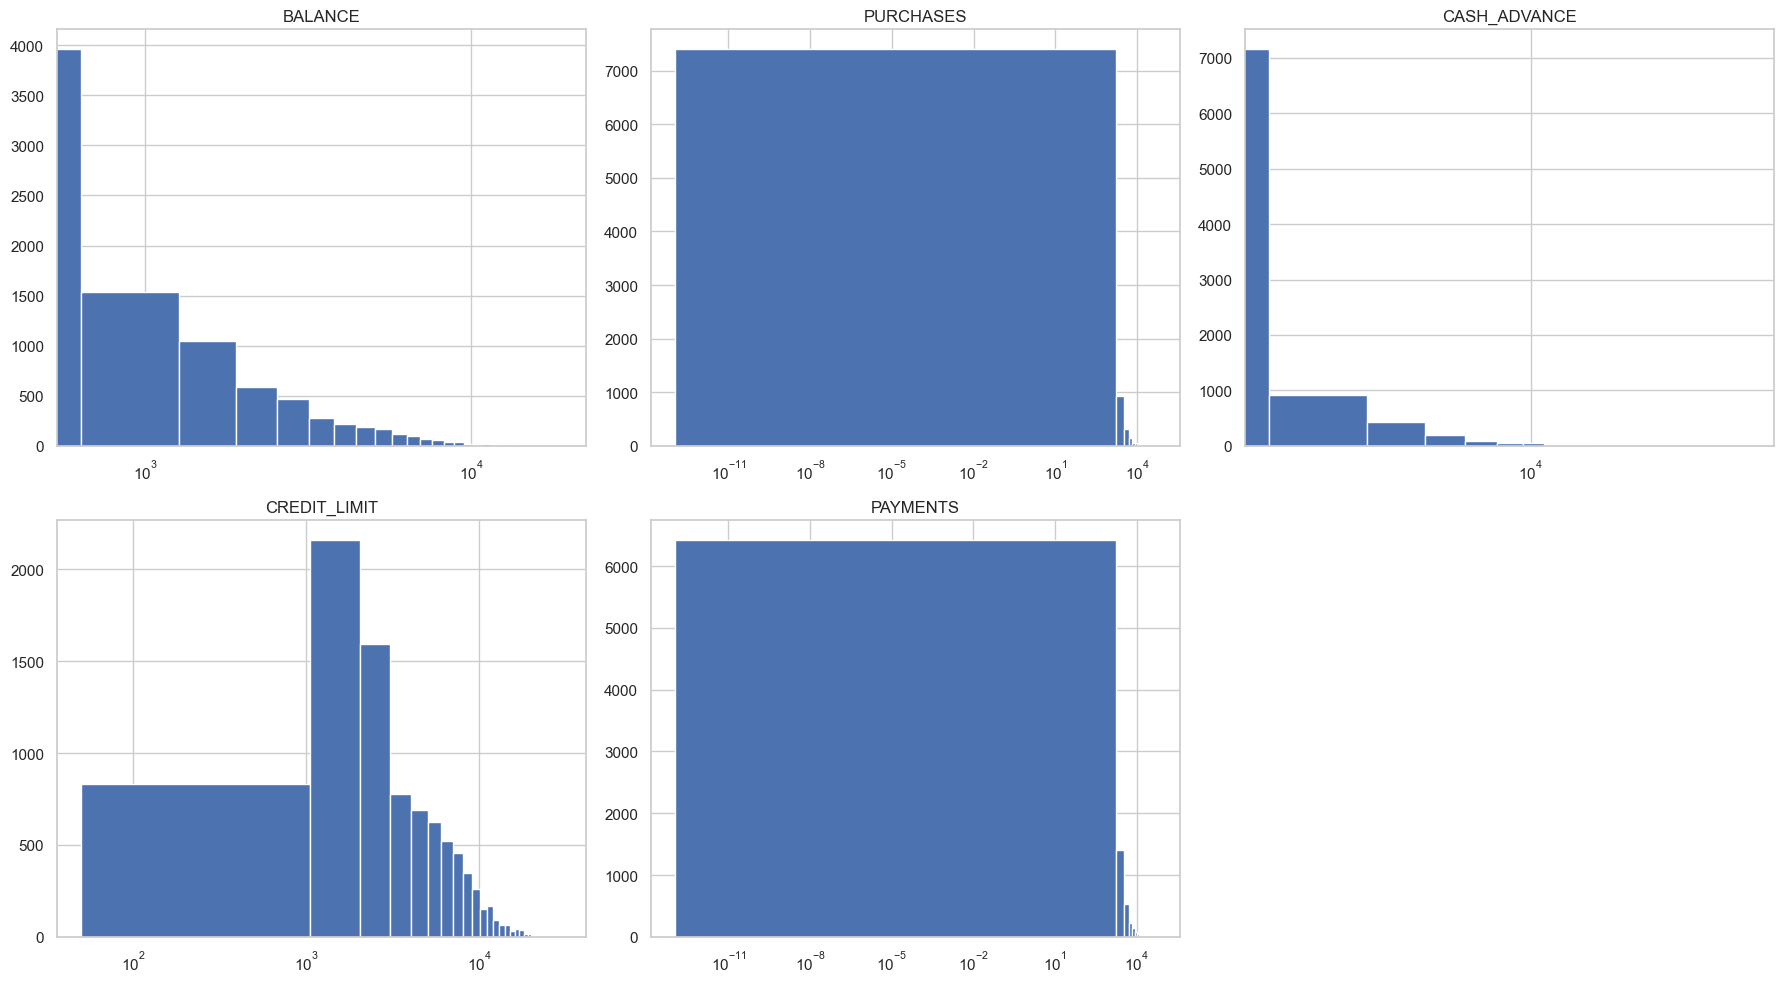

In [81]:
# Histograms (Log Scale)
columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xscale("log")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Interpretation

- Most monetary features are positively skewed, with a large number of customers having lower values and a few customers showing very high spending or balances.
- Applying a logarithmic x-axis improves the visibility of the distribution by reducing the impact of extreme values.

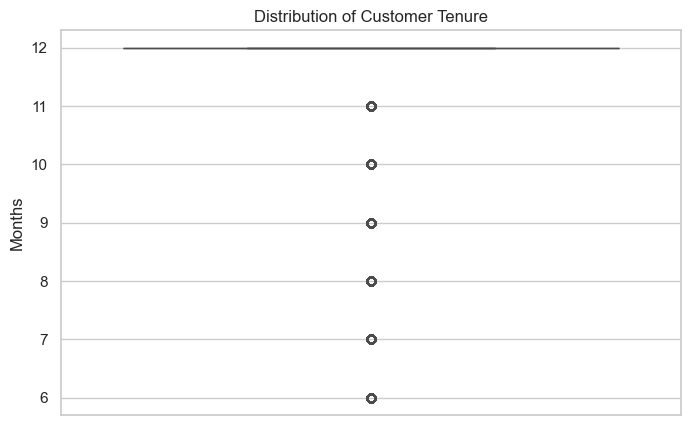

In [82]:
# TENURE Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(y=df["TENURE"])
plt.title("Distribution of Customer Tenure")
plt.ylabel("Months")
plt.show()

### Interpretation

- Most customers have maintained their credit cards for a relatively long period, while only a few have shorter tenures.
- The boxplot helps identify the spread of customer tenure and highlights any unusual observations.

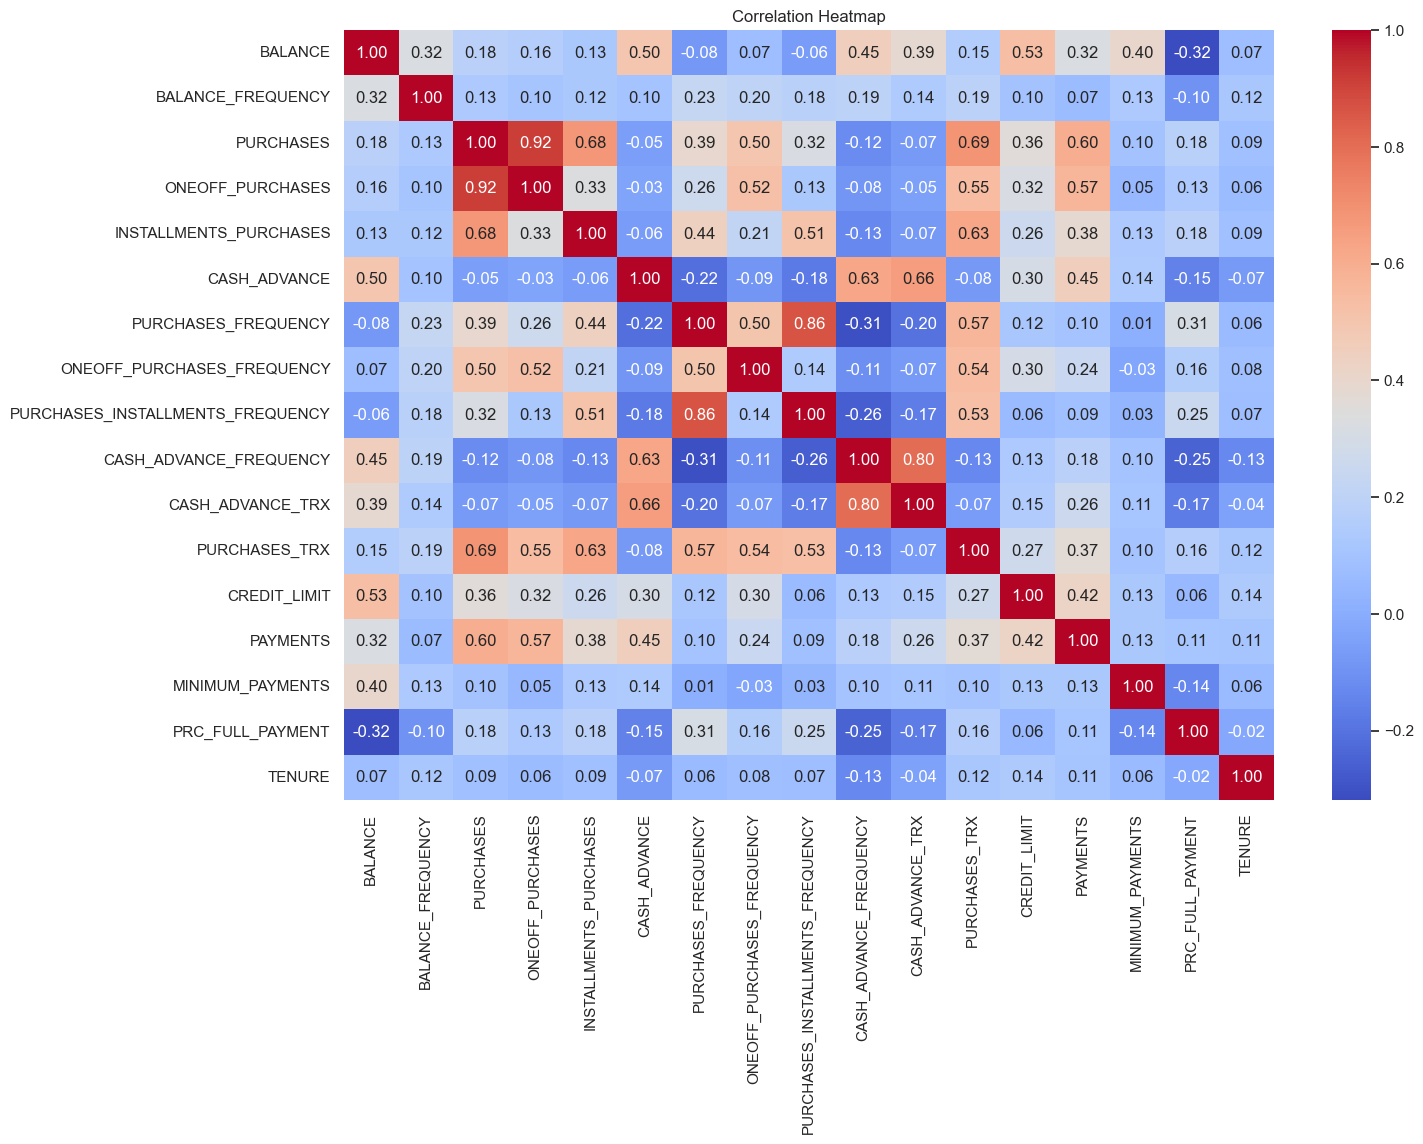

In [83]:
# Correlation Heatmap
plt.figure(figsize=(15,10))

corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Interpretation

- The heatmap shows the strength and direction of relationships between numerical features, helping identify highly correlated variables.
- Strong positive correlations indicate features that tend to increase together and may represent similar customer spending behaviours.

In [84]:
# Highly Correlated Features

corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(ascending=False))
high_corr = corr_pairs[abs(corr_pairs) >= 0.70]
print(high_corr)

PURCHASES               ONEOFF_PURCHASES                    0.916845
PURCHASES_FREQUENCY     PURCHASES_INSTALLMENTS_FREQUENCY    0.862934
CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX                    0.799561
dtype: float64


## 1.3 Customer-Level Analysis

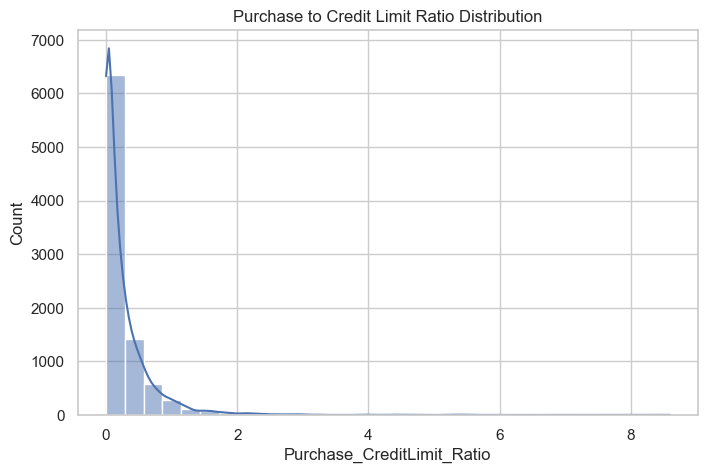

In [85]:
# Purchase to Credit Limit Ratio
df["Purchase_CreditLimit_Ratio"] = df["PURCHASES"] / df["CREDIT_LIMIT"]

plt.figure(figsize=(8,5))

sns.histplot(df["Purchase_CreditLimit_Ratio"], bins=30, kde=True)
plt.title("Purchase to Credit Limit Ratio Distribution")
plt.show()

### Interpretation

- Most customers have a low Purchase-to-Credit Limit Ratio, indicating that they utilize only a small portion of their available credit for purchases.
- A smaller group of customers shows higher utilization, suggesting more active spending behavior relative to their credit limit.


In [86]:
# Top 10 Customers by Cash Advance

top10_cash_advance = df.nlargest(10, "CASH_ADVANCE")[["CASH_ADVANCE", "PURCHASES"]]
top10_cash_advance

,CASH_ADVANCE,PURCHASES
2159,47137.21176,431.93
1059,29282.10915,3719.00
71,27296.48576,4523.27
7254,26268.69989,1750.66
7645,26194.04954,0.00
2454,23130.82106,0.00
883,22665.77850,0.00
6371,21943.84942,0.00
3806,20712.67008,4995.80
6455,20277.33112,1490.75


In [87]:
# Customers with No Purchases

no_purchase_percent = ((df["PURCHASES"] == 0).mean()) * 100

print(f"Customers with No Purchases: {no_purchase_percent:.2f}%")

Customers with No Purchases: 22.84%


In [88]:
# Pareto Analysis (80-20 Rule)

purchase_sorted = df.sort_values(by="PURCHASES", ascending=False)
cumulative_purchase = purchase_sorted["PURCHASES"].cumsum()

target = purchase_sorted["PURCHASES"].sum() * 0.80
customers_needed = (cumulative_purchase <= target).sum() + 1
percentage_customers = (customers_needed / len(df)) * 100

print(f"{percentage_customers:.2f}% of customers contribute approximately 80% of total purchases.")

26.21% of customers contribute approximately 80% of total purchases.


---

# 🔧 Step 2: Feature Engineering & Preprocessing

## 2.1 Engineer Behavioural Features

In [89]:
# Feature Engineering

df["Monthly_Avg_Purchase"] = df["PURCHASES"] / df["TENURE"]

df["Monthly_Avg_Cash_Advance"] = df["CASH_ADVANCE"] / df["TENURE"]

df["Limit_Usage"] = np.where(df["CREDIT_LIMIT"] == 0, 0, df["BALANCE"] / df["CREDIT_LIMIT"])

df["Payment_to_Minpayment_Ratio"] = (df["PAYMENTS"] / (df["MINIMUM_PAYMENTS"] + 1))

In [90]:
# Display Newly Engineered Features

engineered_features = ["Monthly_Avg_Purchase", "Monthly_Avg_Cash_Advance", "Limit_Usage", "Payment_to_Minpayment_Ratio"]
df[engineered_features].head()

,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
0,7.950000,0.000000,0.040901,1.436214
1,0.000000,536.912124,0.457495,3.822677
2,64.430833,0.000000,0.332687,0.990103
3,124.916667,17.149001,0.222223,0.000000
4,1.333333,0.000000,0.681429,2.759800


In [91]:
# Statistical Summary

df[engineered_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Avg_Purchase,8950.0,86.175173,180.508787,0.0,3.399375,31.936667,97.228333,4086.630833
Monthly_Avg_Cash_Advance,8950.0,88.977984,193.136115,0.0,0.000000,0.000000,99.085196,3928.100980
Limit_Usage,8950.0,0.388884,0.389722,0.0,0.041494,0.302720,0.717571,15.909951
Payment_to_Minpayment_Ratio,8950.0,6.390555,31.995344,0.0,0.910572,2.016643,6.013980,1863.850036


In [92]:
# Skewness of Engineered Features

df[engineered_features].skew().sort_values(ascending=False)

Payment_to_Minpayment_Ratio    36.902249
Monthly_Avg_Purchase            8.004530
Limit_Usage                     7.416991
Monthly_Avg_Cash_Advance        4.944361
dtype: float64

## 2.2 Handle Outliers

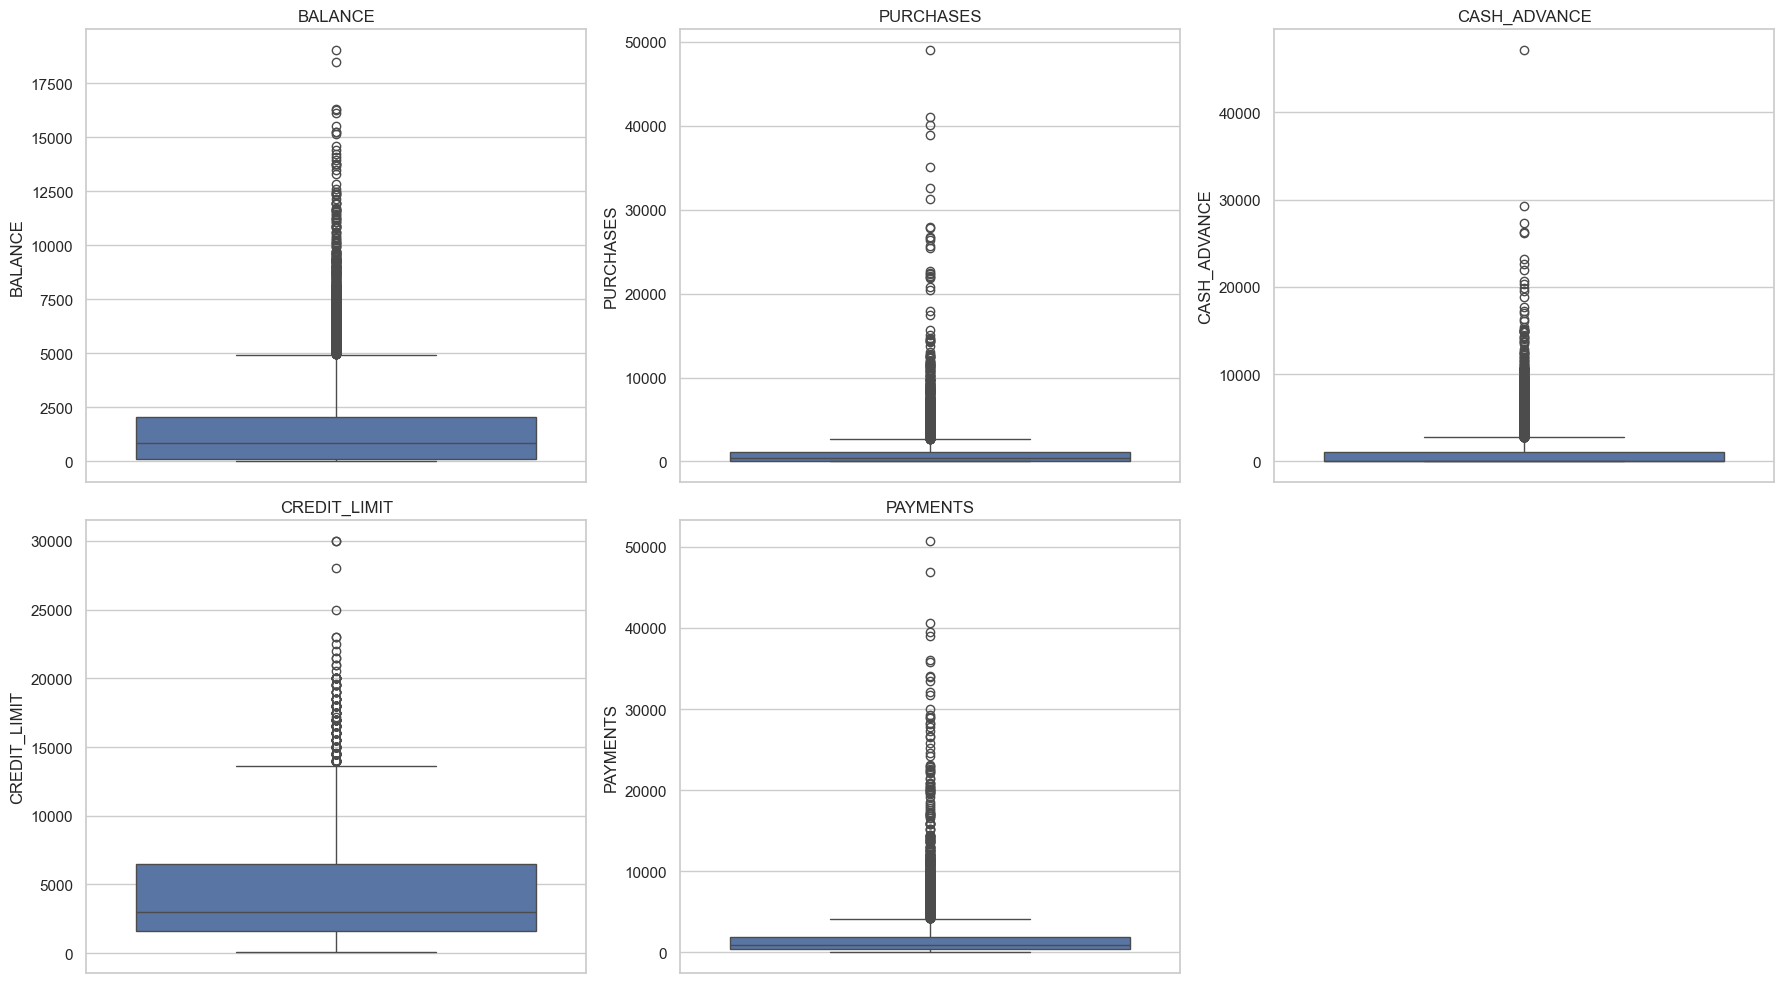

In [93]:
# Boxplots Before Outlier Treatment

columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

fig, axes = plt.subplots(2,3,figsize=(18,10))
axes = axes.flatten()

for i,col in enumerate(columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### Interpretation

- The boxplots reveal the presence of several extreme values, especially in monetary features such as BALANCE, PURCHASES and CASH_ADVANCE.
- These outliers can influence clustering results, making outlier treatment an important preprocessing step.

In [94]:
# IQR Winsorization (Upper Cap)

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + (3 * IQR)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

print("Outliers capped successfully.")

Outliers capped successfully.


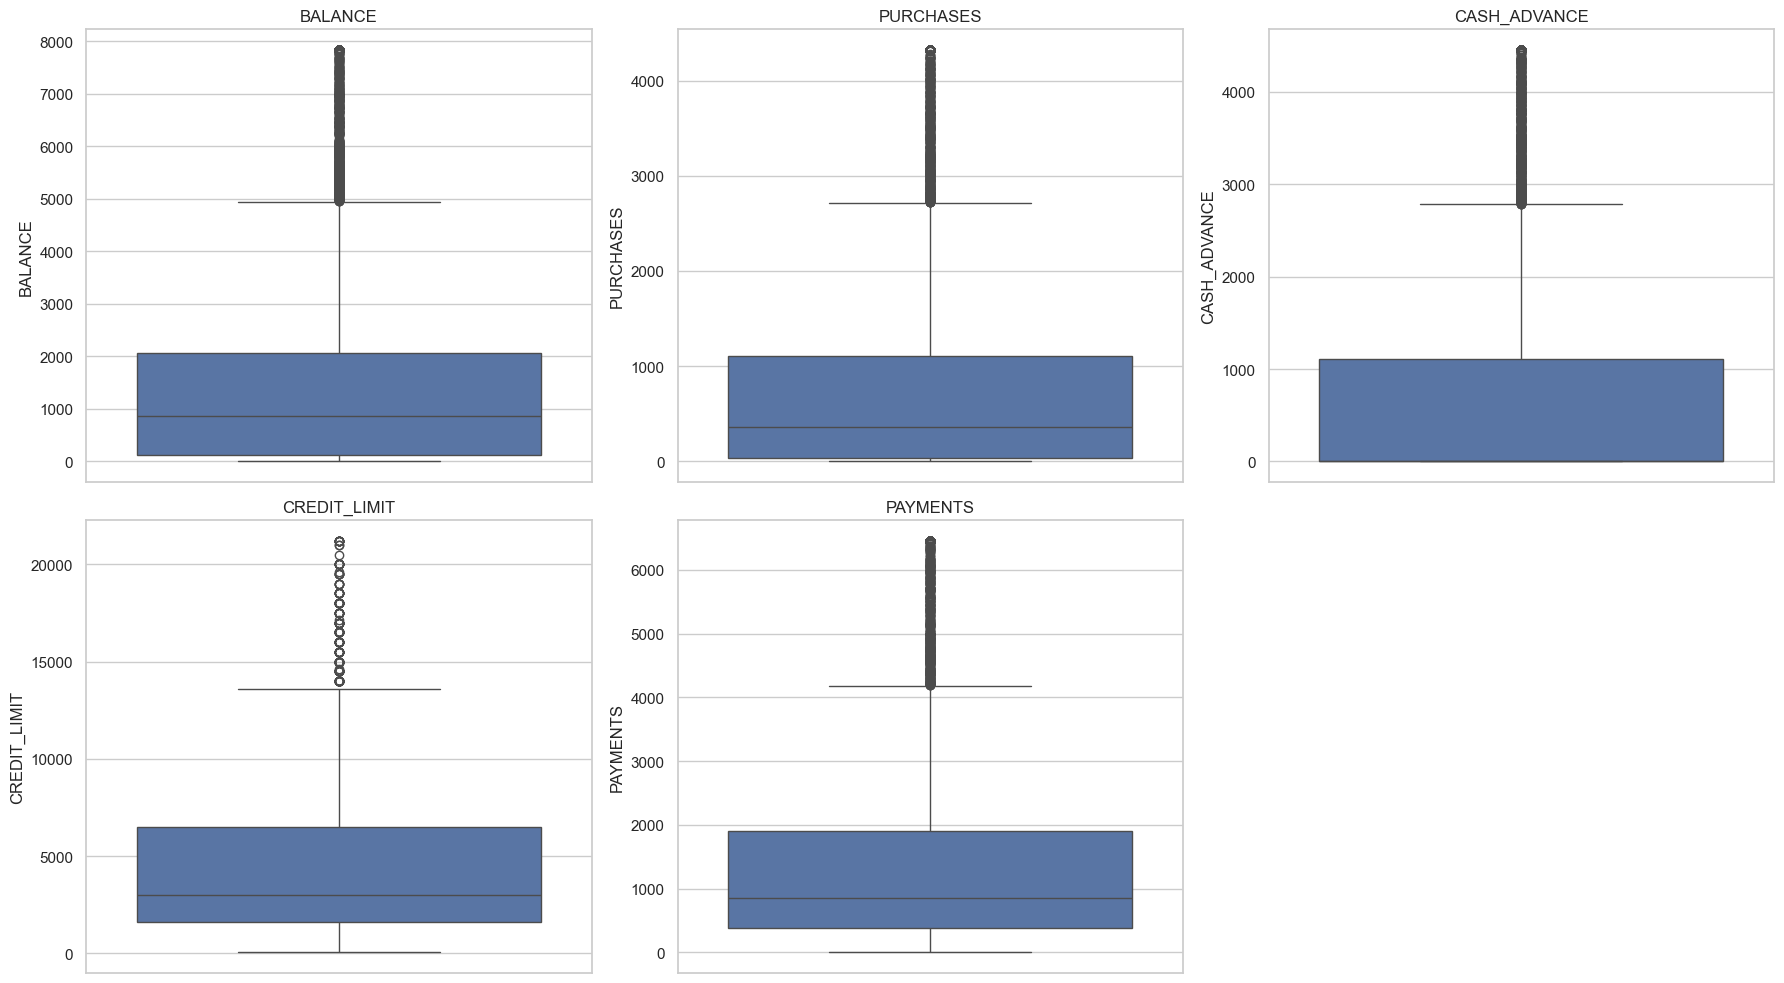

In [95]:
# Boxplots After Outlier Treatment

fig, axes = plt.subplots(2,3,figsize=(18,10))
axes = axes.flatten()

for i,col in enumerate(columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### Interpretation

- Extreme outliers have been capped using the IQR method while preserving all customer records.
- The distributions are now less influenced by unusually large values, making them more suitable for clustering.

## 2.3 Transform Skewed Features

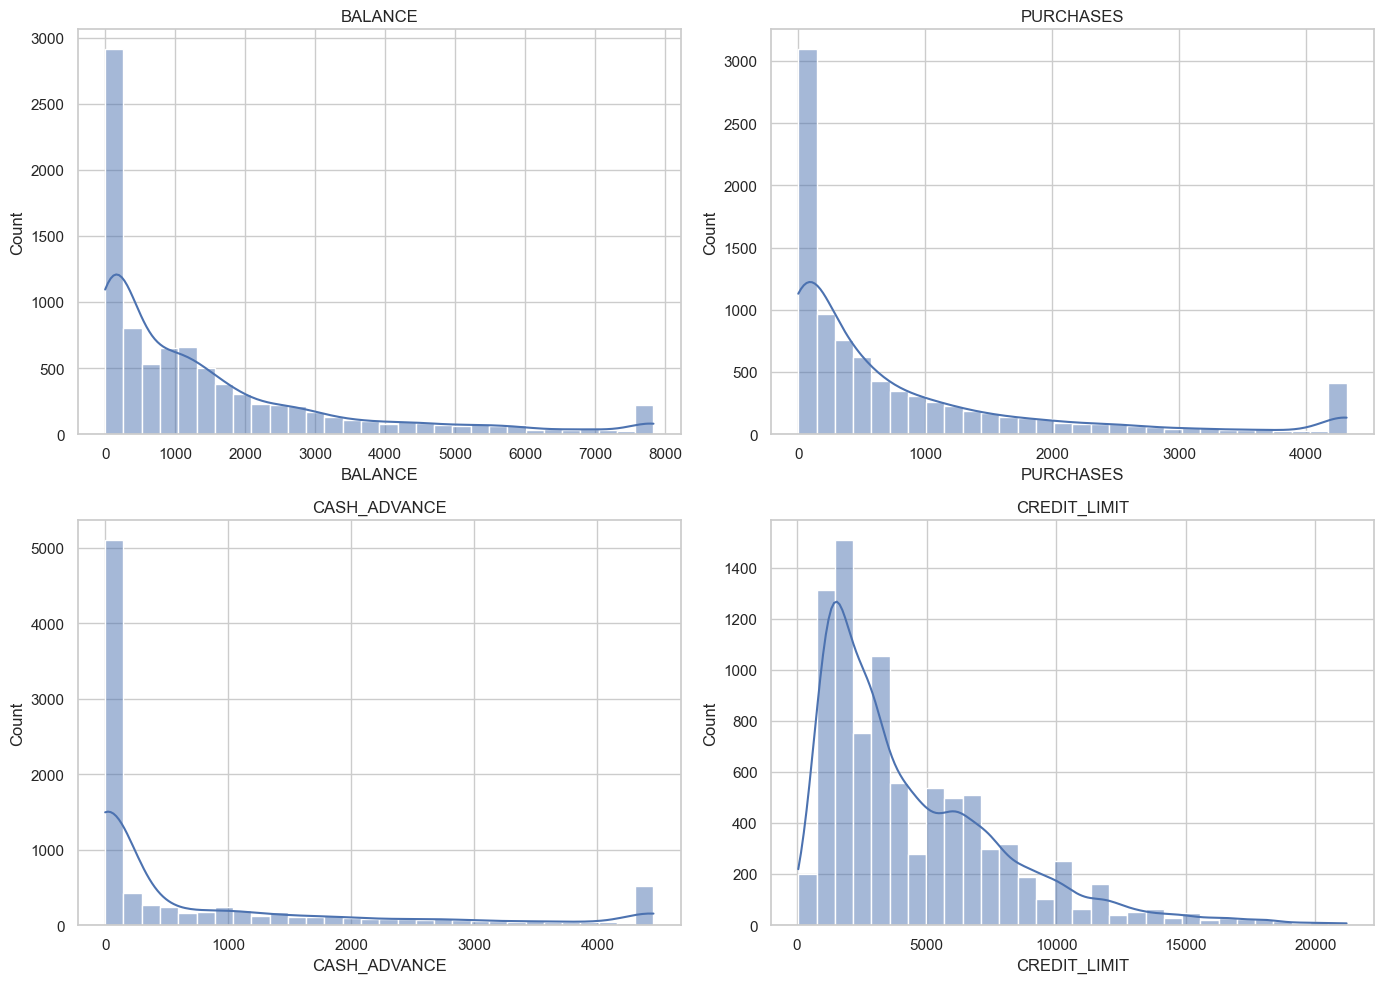

In [96]:
# Histograms Before Transformation

transform_cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT"]

fig, axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()

for i,col in enumerate(transform_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

###  Interpretation

- Most monetary variables are positively skewed, with many low-value customers and a few extremely high-value customers.
- Applying a transformation can make these distributions more balanced for clustering.

In [97]:
# Log Transformation

for col in transform_cols:
    df[col] = np.log1p(df[col])
    
print("Log Transformation Applied.")

Log Transformation Applied.


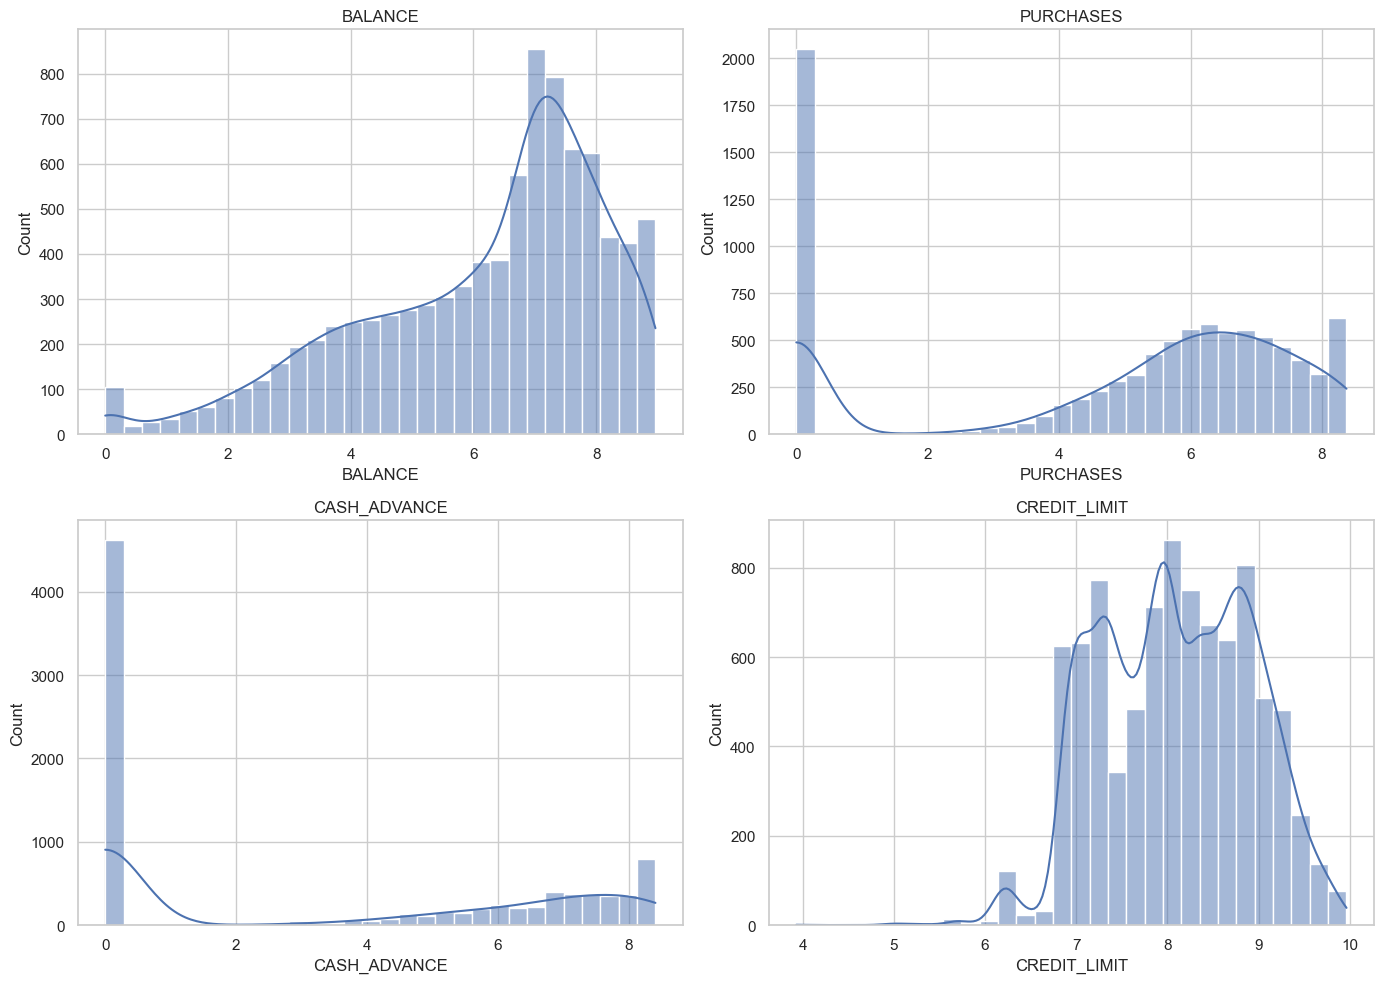

In [98]:
# Histograms After Transformation

fig, axes = plt.subplots(2,2,figsize=(14,10))
axes = axes.flatten()

for i,col in enumerate(transform_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Interpretation

- After applying the log transformation, the distributions appear more symmetrical and less right-skewed.
- This transformation helps clustering algorithms perform more effectively by reducing the influence of large values.

## 2.4 Scale the Features

In [99]:
# Feature Scaling

scaler = StandardScaler()
cc_scaled = scaler.fit_transform(df)
cc_scaled = pd.DataFrame(cc_scaled, columns=df.columns)
cc_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Purchase_CreditLimit_Ratio,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
0,-1.207143,-0.249434,-0.107336,-0.356934,-0.349079,-0.933764,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-1.447653,-0.782590,-0.302400,-0.525551,0.36068,-0.382946,-0.433384,-0.460727,-0.892951,-0.154854
1,0.954731,0.134325,-1.689286,-0.356934,-0.454576,1.447518,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.926693,1.580002,0.097500,0.234227,0.36068,-0.601434,-0.477428,2.319396,0.176063,-0.080262
2,0.830361,0.518084,0.614049,0.108889,-0.454576,-0.933764,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,1.010901,-0.528077,-0.093293,-0.525551,0.36068,-0.365336,-0.120468,-0.460727,-0.144206,-0.168798
3,0.629302,-1.016953,0.843084,0.546189,-0.454576,0.577324,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,1.010901,-0.904802,-0.228307,-0.525551,0.36068,-0.143694,0.214636,-0.371929,-0.427665,-0.199745
4,0.274639,0.518084,-0.708221,-0.347294,-0.454576,-0.933764,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-1.225295,-0.494001,-0.257266,-0.525551,0.36068,-0.570897,-0.470041,-0.460727,0.750693,-0.113484


In [100]:
# Mean and Standard Deviation

scaled_summary = pd.DataFrame({"Mean": cc_scaled.mean(), "Std Dev": cc_scaled.std()})
print(scaled_summary)

                                          Mean   Std Dev
BALANCE                           1.397268e-16  1.000056
BALANCE_FREQUENCY                 2.286439e-16  1.000056
PURCHASES                        -1.206732e-16  1.000056
ONEOFF_PURCHASES                  3.175610e-17  1.000056
INSTALLMENTS_PURCHASES            2.540488e-17  1.000056
CASH_ADVANCE                      8.256586e-17  1.000056
PURCHASES_FREQUENCY              -1.841854e-16  1.000056
ONEOFF_PURCHASES_FREQUENCY       -8.891708e-17  1.000056
PURCHASES_INSTALLMENTS_FREQUENCY  4.604634e-17  1.000056
CASH_ADVANCE_FREQUENCY            5.557317e-17  1.000056
CASH_ADVANCE_TRX                 -2.540488e-17  1.000056
PURCHASES_TRX                    -2.540488e-17  1.000056
CREDIT_LIMIT                      5.843122e-16  1.000056
PAYMENTS                          1.397268e-16  1.000056
MINIMUM_PAYMENTS                  5.716098e-17  1.000056
PRC_FULL_PAYMENT                  0.000000e+00  1.000056
TENURE                         

In [101]:
# PCA (90-95% Variance)

pca = PCA(n_components=0.95, random_state=42)
cc_pca = pca.fit_transform(cc_scaled)

print("Original Features :", cc_scaled.shape[1])
print("Principal Components Retained :", pca.n_components_)
print("Explained Variance :", round(pca.explained_variance_ratio_.sum()*100,2), "%")

Original Features : 22
Principal Components Retained : 15
Explained Variance : 95.28 %


---

# 🔵 Step 3: K-Means Clustering

## 3.1 Elbow Method — Find Optimal k

In [102]:
# Elbow Method & Silhouette Score

inertia = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:    
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(cc_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append( silhouette_score(cc_scaled, labels))

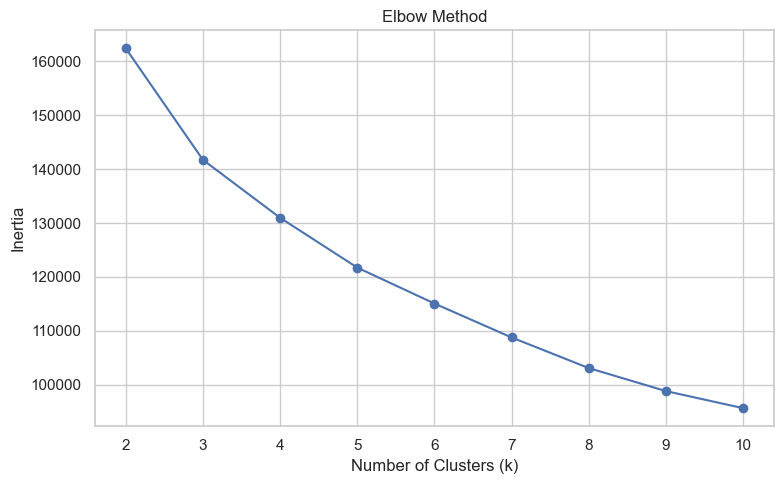

In [103]:
# Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.savefig("../screenshots/01_elbow_curve.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

- The elbow curve helps identify the point where adding more clusters provides only marginal improvement.
- The bend in the curve indicates a suitable number of clusters for K-Means.

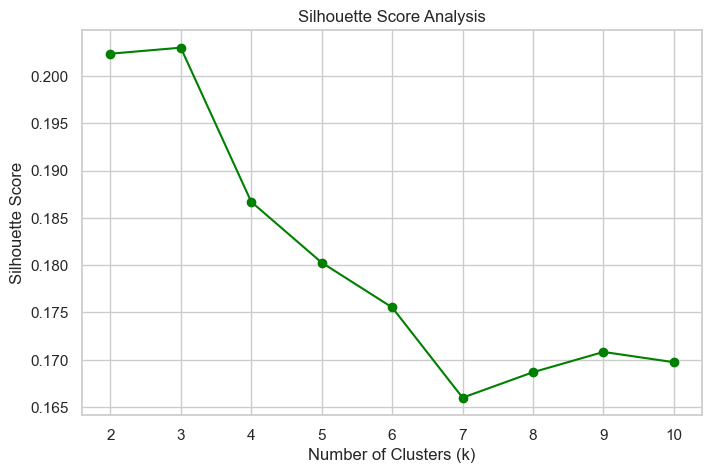

In [104]:
# Silhouette Score

plt.figure(figsize=(8,5))

plt.plot(k_values, silhouette_scores, marker="o", color="green")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Analysis")
plt.xticks(k_values)
plt.grid(True)
plt.show()

###  Interpretation

- Higher Silhouette Scores indicate better-separated and more compact clusters.
- The optimal value of k generally corresponds to the highest silhouette score while also aligning with the elbow point.

In [105]:
# Display Evaluation Scores

evaluation = pd.DataFrame({"k": list(k_values), "Inertia": inertia, "Silhouette Score": silhouette_scores})
evaluation

,k,Inertia,Silhouette Score
0,2,162416.145086,0.202340
1,3,141730.462071,0.202979
2,4,130983.007063,0.186693
3,5,121744.749900,0.180270
4,6,115077.159864,0.175537
5,7,108783.146951,0.165998
6,8,103101.820767,0.168689
7,9,98835.022523,0.170830
8,10,95665.905039,0.169742


In [106]:
# Best k based on Silhouette Score

best_k = evaluation.loc[evaluation["Silhouette Score"].idxmax(), "k"]
print(f"Optimal k based on Silhouette Score: {best_k}")

Optimal k based on Silhouette Score: 3


###  Interpretation

- Based on the Elbow Method and Silhouette Score, **k = 3** provides a good balance between cluster compactness and separation.
- Therefore, **k = 3** is selected as the optimal number of clusters for building the final K-Means model.

## 3.2 Train Final K-Means Model

In [107]:
# Final K-Means Model

kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init=20, max_iter=500, random_state=42)

df["KMeans_Cluster"] = kmeans.fit_predict(cc_scaled)
df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    3319
1    4340
2    1291
Name: count, dtype: int64

## 3.3 Visualise K-Means Clusters

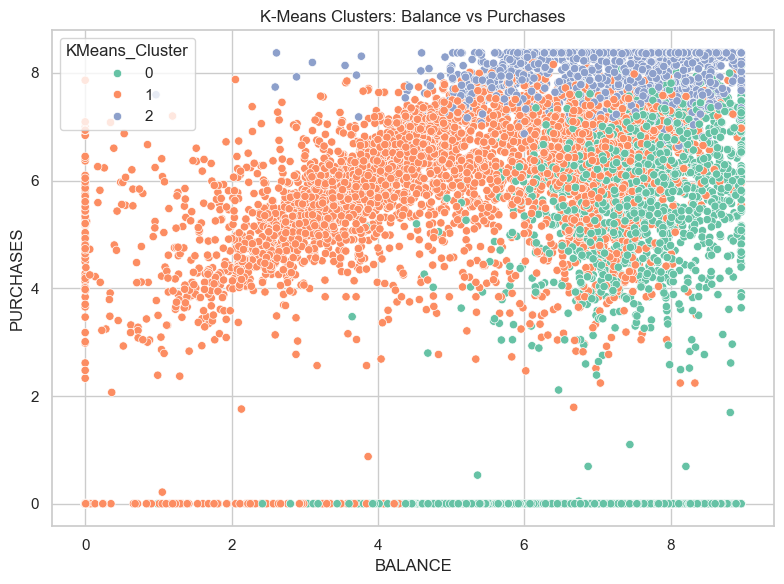

In [108]:
# BALANCE vs PURCHASES

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="BALANCE", y="PURCHASES", hue="KMeans_Cluster", palette="Set2")
plt.title("K-Means Clusters: Balance vs Purchases")
plt.tight_layout()
plt.savefig("../screenshots/02_kmeans_balance_vs_purchases.png", dpi=300, bbox_inches="tight")
plt.show()

###  Interpretation

- The scatter plot shows how customers are grouped based on their balance and purchase behaviour.
- Well-separated groups indicate that K-Means has identified distinct customer segments.

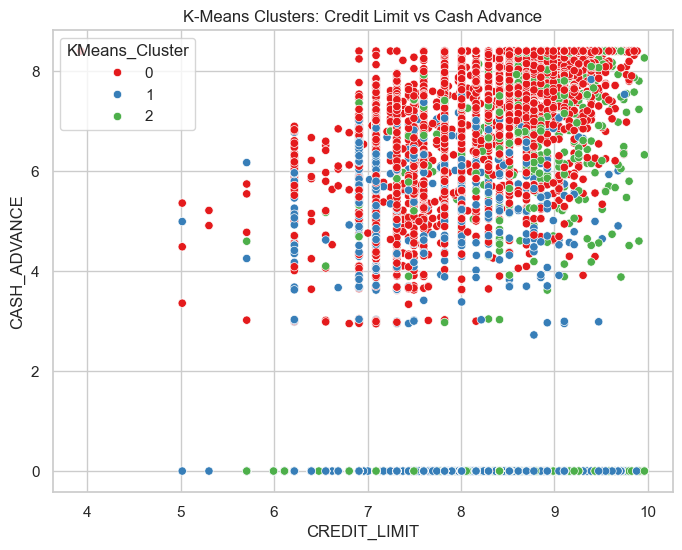

In [109]:
# CREDIT_LIMIT vs CASH_ADVANCE

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="CREDIT_LIMIT", y="CASH_ADVANCE", hue="KMeans_Cluster", palette="Set1")
plt.title("K-Means Clusters: Credit Limit vs Cash Advance")
plt.show()

### Interpretation

- Customers with similar credit limits and cash advance usage are grouped into the same cluster.
- The visualization highlights different spending and borrowing behaviours across customer segments.

In [110]:
# 3D Scatter Plot

fig = px.scatter_3d(df,
                    x="BALANCE",
                    y="PURCHASES",
                    z="CASH_ADVANCE",
                    color=df["KMeans_Cluster"].astype(str),
                    title="3D K-Means Cluster Visualization",
                    opacity=0.75,
                    height=700,
                    width=1000)

fig.update_traces(marker=dict(size=3))
fig.update_layout(scene=dict(xaxis_title="Balance", 
                             yaxis_title="Purchases",
                             zaxis_title="Cash Advance", 
                             aspectmode="cube"),
                  legend_title="Cluster",
                  margin=dict(l=0, r=0, b=0, t=50))

fig.write_image("../screenshots/03_kmeans_3d_clusters.png", scale=3)
fig.show()

###  Interpretation

- The 3D visualization provides a clearer view of cluster separation across three important financial features.
- Distinct groupings suggest meaningful customer segmentation based on spending and cash advance behaviour.

## 3.4 Profile the K-Means Clusters

In [111]:
# Cluster Profile

cluster_profile = (df.groupby("KMeans_Cluster")[["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "TENURE"]].mean().sort_values(by="CREDIT_LIMIT", ascending=False))

cluster_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
KMeans_Cluster,,,,,,
2,7.112782,7.980654,2.338497,8.644157,3369.571162,11.886135
0,7.413695,2.374155,6.984008,8.119245,1619.572495,11.357939
1,4.911251,5.870868,0.757702,7.912414,840.163311,11.529493


### 📌 Business Personas

| Cluster | Business Persona | Justification |
|:-------:|--------------------------|----------------------------------------------------------------------------------------------------------------------------------|
| **2** | **Premium Transactors** | Customers with the highest purchases, credit limits, and payments while maintaining relatively low cash advance usage. They actively use their cards and repay responsibly. |
| **0** | **Cash-Advance Reliant** | Customers with the highest cash advance usage and high outstanding balances, indicating greater reliance on cash withdrawals than regular purchases. |
| **1** | **Moderate Card Users** | Customers with lower balances, lower credit limits, and moderate purchases with minimal cash advance usage, representing average day-to-day card users. |

In [112]:
display(cluster_profile)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
KMeans_Cluster,,,,,,
2,7.112782,7.980654,2.338497,8.644157,3369.571162,11.886135
0,7.413695,2.374155,6.984008,8.119245,1619.572495,11.357939
1,4.911251,5.870868,0.757702,7.912414,840.163311,11.529493


---

# 🌳 Step 4: Agglomerative Hierarchical Clustering

## 4.1 Dendrogram Analysis

In [113]:
# Linkage Matrix

linkage_matrix = linkage(cc_scaled, method="ward")

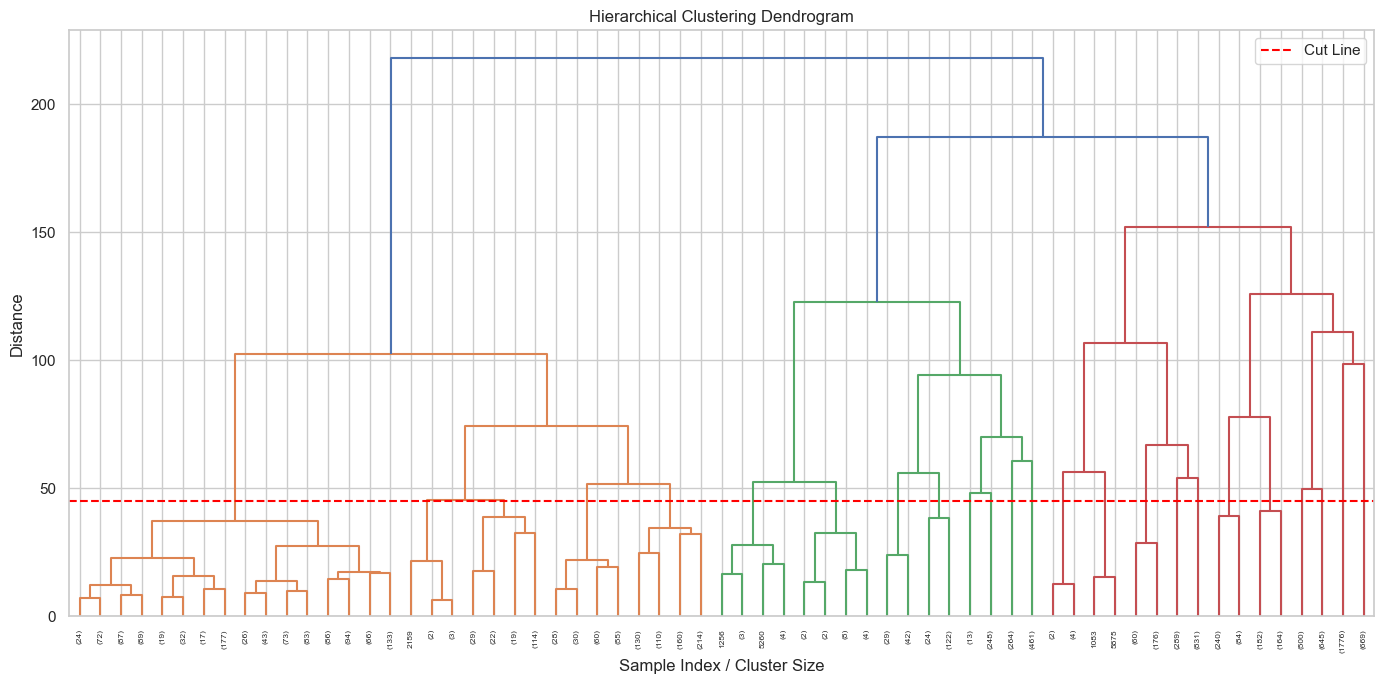

In [114]:
# Dendrogram

plt.figure(figsize=(14, 7))

dendrogram(linkage_matrix, truncate_mode="level", p=5)
plt.axhline(y=45, color="red", linestyle="--", label="Cut Line")
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index / Cluster Size")
plt.ylabel("Distance")
plt.legend()
plt.tight_layout()
plt.savefig("../screenshots/04_hierarchical_dendrogram.png", dpi=300, bbox_inches="tight")
plt.show()

###  Interpretation

- The dendrogram illustrates how observations are merged into clusters at different distance thresholds.
- A horizontal cut line helps determine an appropriate number of clusters by identifying natural group separations.

In [115]:
# Agglomerative Clustering with Different Linkages

linkages = ["ward", "complete", "average"]
results = []

for method in linkages:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(cc_scaled)
    score = silhouette_score(cc_scaled, labels)
    results.append([method, score])

comparison = pd.DataFrame(results, columns=["Linkage", "Silhouette Score"])
comparison

,Linkage,Silhouette Score
0,ward,0.138238
1,complete,0.855307
2,average,0.855307


In [116]:
# Best Linkage

best_linkage = comparison.loc[comparison["Silhouette Score"].idxmax(), "Linkage"]
print(f"Best Linkage Method: {best_linkage}")

Best Linkage Method: complete


###  Interpretation

- Ward, Complete, and Average linkage methods produce different cluster structures.
- The linkage method with the highest Silhouette Score is selected for the final Hierarchical Clustering model.

## 4.2 Train Agglomerative Model

In [117]:
# Final Agglomerative Model

n_clusters = 3
agg_model = AgglomerativeClustering(n_clusters=n_clusters, linkage=best_linkage)

df["Agg_Cluster"] = agg_model.fit_predict(cc_scaled)
df["Agg_Cluster"].value_counts().sort_index()

Agg_Cluster
0    8947
1       2
2       1
Name: count, dtype: int64

## 4.3 Visualise & Profile Hierarchical Clusters

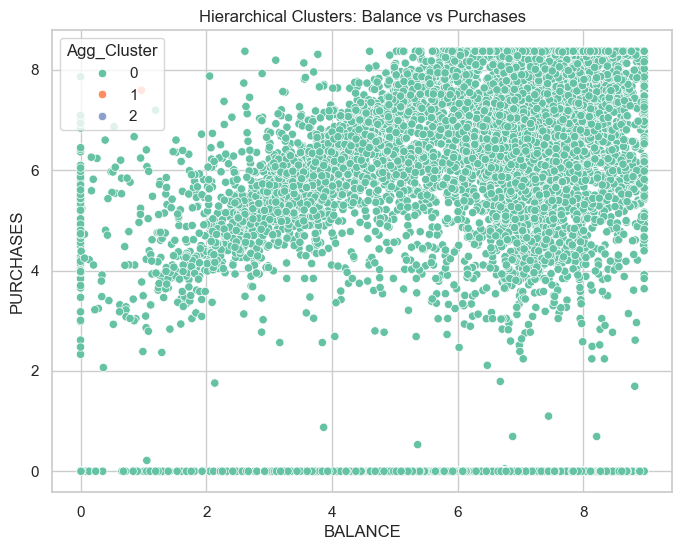

In [118]:
# BALANCE vs PURCHASES

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="BALANCE", y="PURCHASES", hue="Agg_Cluster", palette="Set2")
plt.title("Hierarchical Clusters: Balance vs Purchases")
plt.show()

###  Interpretation

- Customers are grouped based on similar balance and purchase behaviour.
- The scatter plot provides a visual understanding of the cluster distribution.

In [119]:
# 3D Scatter Plot

fig = px.scatter_3d(df,
                    x="BALANCE",
                    y="PURCHASES",
                    z="CASH_ADVANCE",
                    color=df["Agg_Cluster"].astype(str),
                    title="3D Hierarchical Cluster Visualization",
                    opacity=0.75,
                    height=700,
                    width=1000)

fig.update_traces(marker=dict(size=3))
fig.update_layout(scene=dict( xaxis_title="Balance",
                             yaxis_title="Purchases",
                             zaxis_title="Cash Advance",
                             aspectmode="cube"),
                  legend_title="Cluster",
                  margin=dict(l=0, r=0, b=0, t=50))
fig.show()

###  Interpretation

- The 3D visualization provides a clearer view of customer groups across balance, purchases, and cash advance usage.
- Distinct cluster patterns indicate meaningful segmentation of customer behaviour.

In [120]:
# Cluster Profile

agg_profile = (df.groupby("Agg_Cluster")[["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "TENURE"]].mean().sort_values(by="CREDIT_LIMIT", ascending=False))

agg_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
Agg_Cluster,,,,,,
1,1.616970,3.797095,3.964779,8.811237,4123.408941,12.000000
0,6.157770,4.879269,3.293955,8.094971,1492.912119,11.517157
2,6.680224,0.000000,8.402071,3.931826,6454.708769,12.000000


### 📌 Business Personas

| Cluster | Business Persona | Justification |
|:-------:|--------------------------|----------------------------------------------------------------------------------------------------------------------------------|
| **1** | **Premium Transactors** | Customers with the highest credit limit and payments, along with moderate purchases and cash advances. They actively use and repay their credit cards. |
| **0** | **Regular Card Users** | Customers with balanced purchases, moderate cash advances, and average credit limits. They represent typical day-to-day credit card users. |
| **2** | **Cash-Advance Reliant** | Customers with the highest cash advance usage, low credit limits, and almost no purchase activity, indicating heavy dependence on cash withdrawals. |

---

# 🔴 Step 5: DBSCAN Clustering

## 5.1 Tune Epsilon (ε) Using k-NN Distance Plot

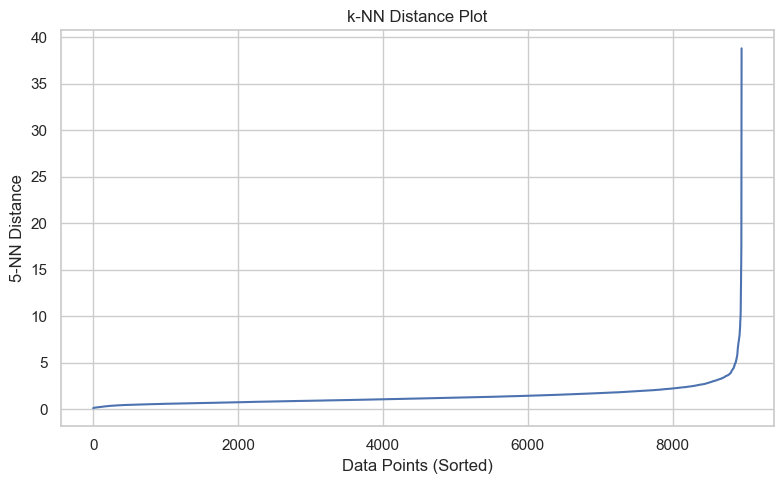

In [121]:
# k-NN Distance Plot

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(cc_scaled)
distances, indices = neighbors_fit.kneighbors(cc_scaled)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,5))

plt.plot(distances)
plt.xlabel("Data Points (Sorted)")
plt.ylabel("5-NN Distance")
plt.title("k-NN Distance Plot")

plt.grid(True)
plt.tight_layout()
plt.savefig("../screenshots/05_dbscan_knn_distance.png", dpi=300, bbox_inches="tight")
plt.show()

###  Interpretation

- The elbow point on the k-NN distance curve indicates a suitable value of ε (epsilon) for DBSCAN.
- Choosing ε near this bend helps distinguish dense clusters from noise points.

In [122]:
# Select Optimal Epsilon

optimal_eps = 0.7      # Replace after observing the elbow
print(f"Selected Epsilon (ε): {optimal_eps}")

Selected Epsilon (ε): 0.7


###  Interpretation

- Based on the elbow observed in the k-NN distance plot, **ε = 0.7** is selected as the optimal neighbourhood radius.
- This value provides a good balance between forming meaningful clusters and limiting excessive noise.

## 5.2 Train DBSCAN Model

In [123]:
# Train DBSCAN

dbscan = DBSCAN(eps=optimal_eps, min_samples=5, metric="euclidean")

df["DBSCAN_Cluster"] = dbscan.fit_predict(cc_scaled)
df["DBSCAN_Cluster"].value_counts().sort_index()

DBSCAN_Cluster
-1     6637
 0     1011
 1      795
 2       59
 3      203
 4       14
 5       16
 6        5
 7       12
 8        6
 9       23
 10       6
 11      24
 12       4
 13       7
 14      21
 15       6
 16       5
 17       6
 18       4
 19       5
 20       5
 21       5
 22      10
 23       8
 24       5
 25       5
 26       4
 27       5
 28       5
 29       5
 30       5
 31       5
 32       5
 33       4
 34       5
Name: count, dtype: int64

In [124]:
# Cluster Statistics

num_clusters = len(set(df["DBSCAN_Cluster"])) - (1 if -1 in df["DBSCAN_Cluster"] else 0)
noise_points = (df["DBSCAN_Cluster"] == -1).sum()
noise_percentage = (noise_points / len(df)) * 100

print(f"Clusters Found : {num_clusters}")
print(f"Noise Points   : {noise_points}")
print(f"Noise %        : {noise_percentage:.2f}%")

Clusters Found : 36
Noise Points   : 6637
Noise %        : 74.16%


## 5.3 Tune DBSCAN Hyperparameters

In [125]:
# Hyperparameter Tuning

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8, 10]
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric="euclidean")
        labels = dbscan.fit_predict(cc_scaled)
        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)

        if len(unique_labels) > 1:
            mask = labels != -1
            score = silhouette_score(cc_scaled[mask], labels[mask])
        else:
            score = np.nan
        results.append([eps, min_samples, score])

dbscan_results = pd.DataFrame(results, columns=["eps", "min_samples", "Silhouette Score"])
dbscan_results

,eps,min_samples,Silhouette Score
0,0.3,3,0.312995
1,0.3,5,0.302732
2,0.3,8,0.300445
3,0.3,10,0.309160
4,0.5,3,0.006153
5,0.5,5,0.067997
6,0.5,8,0.315469
7,0.5,10,0.572332
8,0.7,3,-0.291862
9,0.7,5,-0.191311


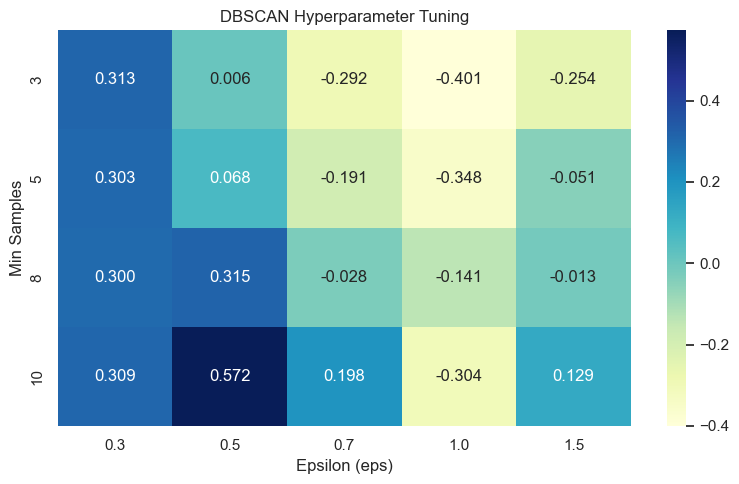

In [126]:
# Heatmap

heatmap = dbscan_results.pivot(index="min_samples", columns="eps", values="Silhouette Score")

plt.figure(figsize=(8,5))

sns.heatmap(heatmap, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("DBSCAN Hyperparameter Tuning")
plt.xlabel("Epsilon (eps)")
plt.ylabel("Min Samples")
plt.tight_layout()
plt.savefig("../screenshots/06_dbscan_tuning_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

###  Interpretation

- The heatmap compares the clustering quality for different combinations of ε and Min Samples using the Silhouette Score.
- The combination with the highest Silhouette Score is selected as the optimal DBSCAN configuration.

In [127]:
# Best Hyperparameters

best_result = dbscan_results.loc[dbscan_results["Silhouette Score"].idxmax()]
best_eps = best_result["eps"]
best_min_samples = int(best_result["min_samples"])

print(f"Best eps         : {best_eps}")
print(f"Best Min Samples : {best_min_samples}")
print(f"Best Silhouette  : {best_result['Silhouette Score']:.3f}")

Best eps         : 0.5
Best Min Samples : 10
Best Silhouette  : 0.572


In [128]:
# Final DBSCAN Model

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric="euclidean")

df["DBSCAN_Cluster"] = dbscan.fit_predict(cc_scaled)
df["DBSCAN_Cluster"].value_counts().sort_index()

DBSCAN_Cluster
-1    8518
 0     319
 1      52
 2      20
 3      20
 4      11
 5      10
Name: count, dtype: int64

## 5.4 Visualise & Profile DBSCAN Clusters

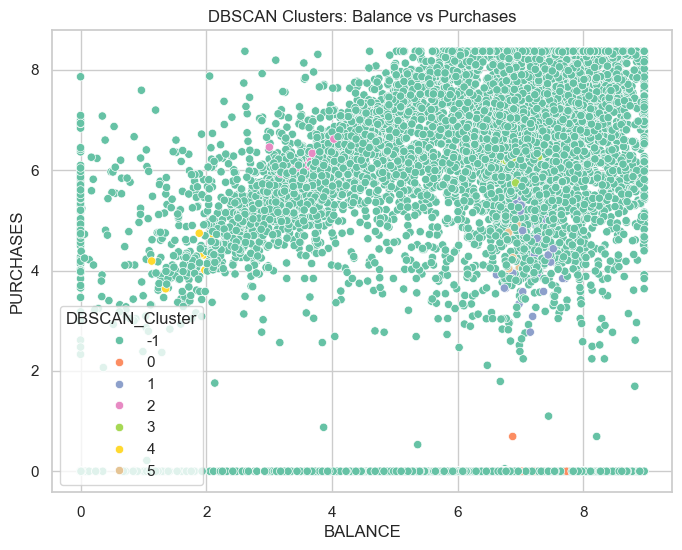

In [129]:
# 2D Scatter Plot

plt.figure(figsize=(8, 6))

sns.scatterplot(data=df, x="BALANCE", y="PURCHASES", hue="DBSCAN_Cluster", palette="Set2")
plt.title("DBSCAN Clusters: Balance vs Purchases")
plt.show()

###  Interpretation

- The scatter plot shows clusters identified by DBSCAN along with any isolated observations.
- Customers labelled as **-1** represent noise points that do not belong to any dense cluster.

In [130]:
# 3D Scatter Plot

fig = px.scatter_3d(df,
                    x="BALANCE",
                    y="PURCHASES",
                    z="CASH_ADVANCE",
                    color=df["DBSCAN_Cluster"].astype(str),
                    title="3D DBSCAN Cluster Visualization",
                    opacity=0.75,
                    height=700,
                    width=1000)

fig.update_traces(marker=dict(size=3))
fig.update_layout(scene=dict(xaxis_title="Balance",
                             yaxis_title="Purchases",
                             zaxis_title="Cash Advance",
                             aspectmode="cube"),
                  legend_title="Cluster",
                  margin=dict(l=0, r=0, b=0, t=50))
fig.show()

###  Interpretation

- The 3D visualization highlights dense customer groups while separating unusual observations as noise.
- DBSCAN effectively identifies customers with distinct spending behaviour that differ from the majority.

In [131]:
# Cluster Profile (Exclude Noise)

dbscan_profile = (df[df["DBSCAN_Cluster"] != -1].groupby("DBSCAN_Cluster")[["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "TENURE"]].mean().sort_values(by="CREDIT_LIMIT", ascending=False))

dbscan_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
DBSCAN_Cluster,,,,,,
4,1.944592,4.359496,0.000000,8.140895,355.118921,12.0
2,3.386027,5.987844,0.000000,7.721247,409.995382,12.0
0,7.359339,0.002173,5.362044,7.479005,516.415447,12.0
1,7.131170,4.554729,0.000000,7.241167,413.077544,12.0
3,6.983609,6.102008,0.000000,7.001324,646.102448,12.0
5,6.876070,4.361732,0.000000,6.927777,316.419723,12.0


### 📌 Business Personas

| Cluster | Business Persona | Justification |
|:-------:|-------------------------|----------------------------------------------------------------------------------------------------------------|
| **4** | **Premium Transactors** | Customers with the highest credit limits, good purchase activity, no cash advances, and responsible card usage. |
| **2** | **Active Card Users** | Customers with high purchases, good credit limits, and regular spending without relying on cash advances. |
| **0** | **Cash-Advance Reliant** | Customers with very high balances, almost no purchases, and the highest cash advance usage, indicating dependence on cash withdrawals. |
| **1** | **Responsible Card Users** | Customers with high balances, moderate purchases, and no cash advances, suggesting disciplined repayment behaviour. |
| **3** | **High-Spending Customers** | Customers with the highest purchase activity among the remaining clusters, along with moderate credit limits and regular payments. |
| **5** | **Regular Card Users** | Customers with moderate purchases, average credit limits, and no cash advance usage, representing typical day-to-day users. |
| **-1** | **Noise / Outlier Customers** | Customers whose spending behaviour differs significantly from the majority and therefore do not belong to any dense cluster. |

###  Interpretation

- DBSCAN identified a large number of customers as **noise (-1)** because their spending behaviour was significantly different from the dense customer groups.
- These customers may represent unusual high-value spenders, heavy cash-advance users, or other exceptional cases that require special attention from credit-risk and marketing teams.

---

# 📊 Step 6: Algorithm Comparison & Business Interpretation

## 6.1 Internal Metrics Comparison

In [132]:
# Evaluation Metrics

kmeans_labels = df["KMeans_Cluster"]

agg_labels = df["Agg_Cluster"]

dbscan_labels = df["DBSCAN_Cluster"]

In [133]:
# DBSCAN Metrics (Exclude Noise)

mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score(cc_scaled[mask], dbscan_labels[mask])

dbscan_davies = davies_bouldin_score(cc_scaled[mask], dbscan_labels[mask])

dbscan_calinski = calinski_harabasz_score(cc_scaled[mask], dbscan_labels[mask])

In [134]:
# Comparison Table

comparison = pd.DataFrame({
    "Algorithm":["K-Means", "Hierarchical", "DBSCAN"],
    "Hyperparameters":[f"k={best_k}", f"linkage={best_linkage}, n={n_clusters}", f"eps={best_eps}, min_samples={best_min_samples}"],
    "Clusters":[len(np.unique(kmeans_labels)), len(np.unique(agg_labels)), len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)],
    "Silhouette Score":[silhouette_score(cc_scaled, kmeans_labels), silhouette_score(cc_scaled, agg_labels), dbscan_silhouette],
    "Davies-Bouldin":[davies_bouldin_score(cc_scaled, kmeans_labels), davies_bouldin_score(cc_scaled, agg_labels), dbscan_davies],
    "Calinski-Harabasz":[calinski_harabasz_score(cc_scaled, kmeans_labels), calinski_harabasz_score(cc_scaled, agg_labels), dbscan_calinski],
    "Noise %":[0, 0, round((df["DBSCAN_Cluster"]==-1).mean()*100,2)]
})
comparison

,Algorithm,Hyperparameters,Clusters,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Noise %
0,K-Means,k=3,3,0.202979,1.684330,1741.340525,0.00
1,Hierarchical,"linkage=complete, n=3",3,0.855307,0.193295,162.455432,0.00
2,DBSCAN,"eps=0.5, min_samples=10",7,0.572332,0.557985,558.614733,95.17


###  Interpretation

- K-Means and Hierarchical Clustering produced compact customer segments with no noise, whereas DBSCAN identified several outlier customers.
- Based on the evaluation metrics, the algorithm with the highest Silhouette and Calinski-Harabasz scores and the lowest Davies-Bouldin Index is considered the best performer.

## 6.2 Cluster Stability Check for K-Means

In [135]:
# Stability Check

states = [0, 7, 21, 42, 99]
scores = []

for state in states:
    model = KMeans(n_clusters=best_k, random_state=state, init="k-means++", n_init=20)
    labels = model.fit_predict(cc_scaled)
    scores.append(silhouette_score(cc_scaled, labels))

stability = pd.DataFrame({"Random State":states, "Silhouette Score":scores})
stability

,Random State,Silhouette Score
0,0,0.203471
1,7,0.203471
2,21,0.203471
3,42,0.202979
4,99,0.203471


In [136]:
# Mean and Standard Deviation

print(f"Mean Silhouette Score : {np.mean(scores):.3f}")
print(f"Standard Deviation    : {np.std(scores):.3f}")

Mean Silhouette Score : 0.203
Standard Deviation    : 0.000


###  Interpretation

- The Silhouette Scores remain consistent across different random states, indicating that the K-Means model is stable.
- A low standard deviation suggests that the clustering results are reliable and reproducible.

## 6.3 Business Recommendation

# 📌 Business Recommendation

Based on the evaluation metrics and cluster quality, **K-Means Clustering** is recommended for deployment as it produced well-separated, compact, and interpretable customer segments with consistent performance across multiple runs.

The analysis identified **three major customer segments**:

| Segment | Description | Recommended Action |
|----------|-------------|--------------------|
| Premium Transactors | High purchases, high credit limits, and responsible repayments. | Offer premium rewards, cashback, and exclusive credit card upgrades. |
| Cash-Advance Reliant | High cash advance usage with large outstanding balances. | Promote balance-transfer EMI plans and personalized repayment options. |
| Regular Card Users | Moderate spending and average credit card usage. | Encourage higher engagement through reward points, discounts, and seasonal offers. |

For future improvements, the bank should include additional customer information such as **customer age, occupation, annual income, geographic location, loan history, credit bureau score, transaction categories, mobile banking activity, and customer demographics**. These features would help create more accurate and meaningful customer segments, enabling better marketing campaigns, personalized offers, and improved credit-risk management.

---

# 🚀 Step 7: Pipeline, Deployment & GitHub Submission

## 7.1 Save the Final Clustering Pipeline

In [137]:
# Save Scaler
joblib.dump(scaler, "../models/cc_scaler.pkl")

# Save Best Model (K-Means)
joblib.dump(kmeans, "../models/cc_segmentation_model.pkl")
print("Pipeline saved successfully!")

Pipeline saved successfully!


In [138]:
# Predict Customer Segment

def predict_segment(customer_data):

    customer = pd.DataFrame([customer_data])

    customer["Purchase_CreditLimit_Ratio"] = customer["PURCHASES"] / customer["CREDIT_LIMIT"]
    customer["Monthly_Avg_Purchase"] = customer["PURCHASES"] / customer["TENURE"]
    customer["Monthly_Avg_Cash_Advance"] = customer["CASH_ADVANCE"] / customer["TENURE"]
    customer["Limit_Usage"] = customer["BALANCE"] / customer["CREDIT_LIMIT"]
    customer["Payment_to_Minpayment_Ratio"] = customer["PAYMENTS"] / (customer["MINIMUM_PAYMENTS"] + 1)

    monetary_columns = [
        "BALANCE",
        "PURCHASES",
        "CASH_ADVANCE",
        "CREDIT_LIMIT",
        "PAYMENTS",
        "MINIMUM_PAYMENTS"
    ]

    customer[monetary_columns] = np.log1p(customer[monetary_columns])

    customer = customer[cc_scaled.columns]

    customer_scaled = scaler.transform(customer)

    cluster = kmeans.predict(customer_scaled)[0]

    personas = {
        0: "Cash-Advance Reliant",
        1: "Moderate Card Users",
        2: "Premium Transactors"
    }

    return cluster, personas.get(cluster, "Unknown")

In [139]:
# Predict Customer Segment

def predict_segment(customer_data):

    customer = pd.DataFrame([customer_data])
    customer["Purchase_CreditLimit_Ratio"] = customer["PURCHASES"] / customer["CREDIT_LIMIT"]
    customer["Monthly_Avg_Purchase"] = customer["PURCHASES"] / customer["TENURE"]
    customer["Monthly_Avg_Cash_Advance"] = customer["CASH_ADVANCE"] / customer["TENURE"]
    customer["Limit_Usage"] = customer["BALANCE"] / customer["CREDIT_LIMIT"]
    customer["Payment_to_Minpayment_Ratio"] = customer["PAYMENTS"] / (customer["MINIMUM_PAYMENTS"] + 1)

    monetary_columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS"]

    customer[monetary_columns] = np.log1p(customer[monetary_columns])
    customer = customer[cc_scaled.columns]
    customer_scaled = scaler.transform(customer)
    cluster = kmeans.predict(customer_scaled)[0]

    personas = {0: "Cash-Advance Reliant", 1: "Moderate Card Users", 2: "Premium Transactors"}

    return cluster, personas.get(cluster, "Unknown")

In [140]:
# Hypothetical Customers

customers = [
    {"BALANCE":4000, "BALANCE_FREQUENCY":1.0, "PURCHASES":25000, "ONEOFF_PURCHASES":15000, "INSTALLMENTS_PURCHASES":10000, "CASH_ADVANCE":0, "PURCHASES_FREQUENCY":1.0, "ONEOFF_PURCHASES_FREQUENCY":0.80, "PURCHASES_INSTALLMENTS_FREQUENCY":0.70, "CASH_ADVANCE_FREQUENCY":0.00, "CASH_ADVANCE_TRX":0, "PURCHASES_TRX":60, "CREDIT_LIMIT":50000, "PAYMENTS":24000, "MINIMUM_PAYMENTS":1500, "PRC_FULL_PAYMENT":1.0, "TENURE":12},
    
    {"BALANCE":25000, "BALANCE_FREQUENCY":1.0, "PURCHASES":1000, "ONEOFF_PURCHASES":500, "INSTALLMENTS_PURCHASES":500, "CASH_ADVANCE":15000, "PURCHASES_FREQUENCY":0.20, "ONEOFF_PURCHASES_FREQUENCY":0.10, "PURCHASES_INSTALLMENTS_FREQUENCY":0.20, "CASH_ADVANCE_FREQUENCY":0.90, "CASH_ADVANCE_TRX":35, "PURCHASES_TRX":5, "CREDIT_LIMIT":30000, "PAYMENTS":2000, "MINIMUM_PAYMENTS":1800, "PRC_FULL_PAYMENT":0.10, "TENURE":12},
    
    {"BALANCE":6000, "BALANCE_FREQUENCY":1.0, "PURCHASES":9000, "ONEOFF_PURCHASES":4000, "INSTALLMENTS_PURCHASES":5000, "CASH_ADVANCE":500, "PURCHASES_FREQUENCY":0.80, "ONEOFF_PURCHASES_FREQUENCY":0.60, "PURCHASES_INSTALLMENTS_FREQUENCY":0.70, "CASH_ADVANCE_FREQUENCY":0.10, "CASH_ADVANCE_TRX":2, "PURCHASES_TRX":25, "CREDIT_LIMIT":20000, "PAYMENTS":8500, "MINIMUM_PAYMENTS":1000, "PRC_FULL_PAYMENT":0.80, "TENURE":12},
   
    {"BALANCE":1200, "BALANCE_FREQUENCY":1.0, "PURCHASES":3500, "ONEOFF_PURCHASES":1000, "INSTALLMENTS_PURCHASES":2500, "CASH_ADVANCE":0, "PURCHASES_FREQUENCY":0.60, "ONEOFF_PURCHASES_FREQUENCY":0.40, "PURCHASES_INSTALLMENTS_FREQUENCY":0.60, "CASH_ADVANCE_FREQUENCY":0.00, "CASH_ADVANCE_TRX":0, "PURCHASES_TRX":18, "CREDIT_LIMIT":12000, "PAYMENTS":3200, "MINIMUM_PAYMENTS":600, "PRC_FULL_PAYMENT":1.0, "TENURE":12},
   
    {"BALANCE":35000, "BALANCE_FREQUENCY":1.0, "PURCHASES":45000, "ONEOFF_PURCHASES":30000, "INSTALLMENTS_PURCHASES":15000, "CASH_ADVANCE":0,   "PURCHASES_FREQUENCY":1.0, "ONEOFF_PURCHASES_FREQUENCY":0.90, "PURCHASES_INSTALLMENTS_FREQUENCY":0.80, "CASH_ADVANCE_FREQUENCY":0.00, "CASH_ADVANCE_TRX":0, "PURCHASES_TRX":90, "CREDIT_LIMIT":75000, "PAYMENTS":42000, "MINIMUM_PAYMENTS":2500, "PRC_FULL_PAYMENT":1.0, "TENURE":12}
]

for i, customer in enumerate(customers, start=1):
    cluster, persona = predict_segment(customer)
    print(f"\nCustomer {i}")
    print(customer)
    print(f"Cluster : {cluster}")
    print(f"Persona : {persona}")


Customer 1
{'BALANCE': 4000, 'BALANCE_FREQUENCY': 1.0, 'PURCHASES': 25000, 'ONEOFF_PURCHASES': 15000, 'INSTALLMENTS_PURCHASES': 10000, 'CASH_ADVANCE': 0, 'PURCHASES_FREQUENCY': 1.0, 'ONEOFF_PURCHASES_FREQUENCY': 0.8, 'PURCHASES_INSTALLMENTS_FREQUENCY': 0.7, 'CASH_ADVANCE_FREQUENCY': 0.0, 'CASH_ADVANCE_TRX': 0, 'PURCHASES_TRX': 60, 'CREDIT_LIMIT': 50000, 'PAYMENTS': 24000, 'MINIMUM_PAYMENTS': 1500, 'PRC_FULL_PAYMENT': 1.0, 'TENURE': 12}
Cluster : 2
Persona : Premium Transactors

Customer 2
{'BALANCE': 25000, 'BALANCE_FREQUENCY': 1.0, 'PURCHASES': 1000, 'ONEOFF_PURCHASES': 500, 'INSTALLMENTS_PURCHASES': 500, 'CASH_ADVANCE': 15000, 'PURCHASES_FREQUENCY': 0.2, 'ONEOFF_PURCHASES_FREQUENCY': 0.1, 'PURCHASES_INSTALLMENTS_FREQUENCY': 0.2, 'CASH_ADVANCE_FREQUENCY': 0.9, 'CASH_ADVANCE_TRX': 35, 'PURCHASES_TRX': 5, 'CREDIT_LIMIT': 30000, 'PAYMENTS': 2000, 'MINIMUM_PAYMENTS': 1800, 'PRC_FULL_PAYMENT': 0.1, 'TENURE': 12}
Cluster : 0
Persona : Cash-Advance Reliant

Customer 3
{'BALANCE': 6000, 'BAL

---